# Introduction

Credit risk assessment is one of the most critical applications of data science in the financial sector. When a bank or financial institution receives a loan application, they must decide whether to approve it based on the likelihood of the applicant repaying the debt. Manually reviewing every application is time-consuming and can result in human error.

# Problem Statement

The objective of this project is to build a classification model that predicts Loan Status (Approved or Rejected). By analyzing historical data on applicant income, credit history, education, and loan amount, the aim to develop a model that can assist financial institutions in minimizing defaults while maximizing successful repayments.

# Dataset Understanding and Description:

The Loan Prediction Dataset contains information about applicants who have applied for loans in the past. It includes a mix of categorical, numerical, and boolean data.

Feature Breakdown
ApplicantIncome & CoapplicantIncome: Numerical data representing the household's earning capacity.

LoanAmount: The requested loan sum.

Credit_History: A binary feature (0 or 1) indicating if the user has a history of meeting financial obligations. This is often the most significant predictor.

Education: Categorical (Graduate/Undergraduate).

Property_Area: Urban, Semi-Urban, or Rural.

Loan_Status: The target variable (Y/N) and some other features.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Data Loading and Analysis

In [3]:
df = pd.read_csv('LoanPrediction.csv')

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [9]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

# Filling missing values

In [13]:
#filling object/string type missing values with mode(most common) occurring values

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)


In [14]:
#filling the missing values in numeric columns with mean

df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean(), inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mean(), inplace=True)
 

# Visualization

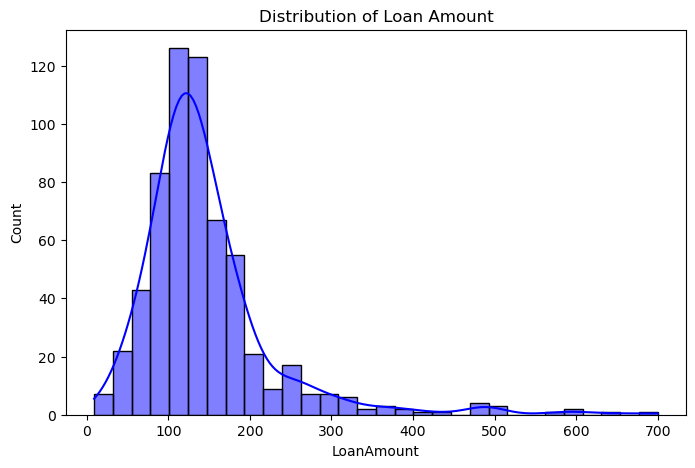

In [15]:
# Loan Amount Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['LoanAmount'], bins=30, kde=True, color='blue')
plt.title('Distribution of Loan Amount')
plt.show()

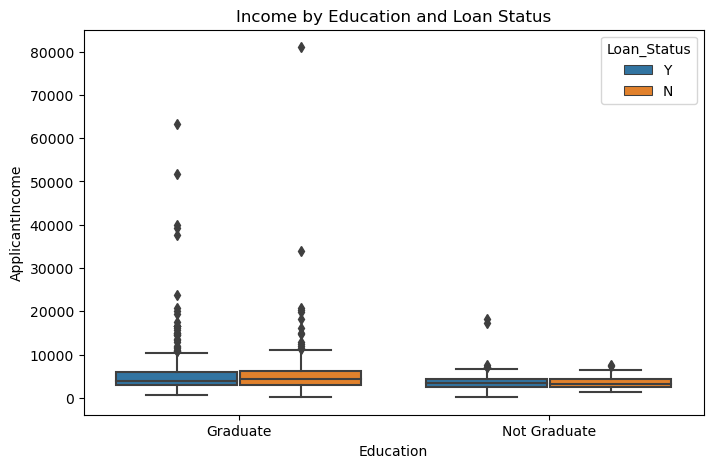

In [19]:
# Income and Loan Status by Education

plt.figure(figsize=(8, 5))
sns.boxplot(x='Education', y='ApplicantIncome', hue='Loan_Status', data=df)
plt.title('Income by Education and Loan Status')
plt.show()

# Model Training

In [21]:
# Encoding the categorical target

le = LabelEncoder()
df['Loan_Status'] = le.fit_transform(df['Loan_Status']) 
# Loan_Status becomes: 1 → Approved , 0 → Denied

# Defining features (X) and target (y)

X = df[['ApplicantIncome', 'LoanAmount']] 
y = df['Loan_Status']

# Spliting the data such that 80% training and 20% testing

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the Logistic Regression model

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

# Model Evaluation 

Model Accuracy: 65.04%


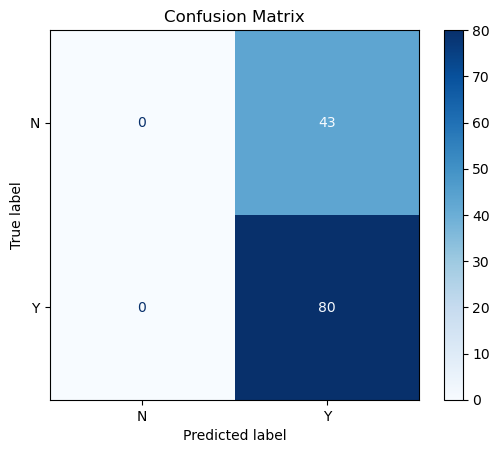

In [25]:
# Making predictions

y_pred = model.predict(X_test)

#Calculating Accuracy

accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy * 100:.2f}%')

# Displaying Confusion Matrix for Model Evaluation

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Conclusion

After training the model and evaluating the performance, several insights were gained:

Credit History: The visualization and model coefficients suggest that Credit_History is the strongest predictor of loan approval. Applicants with a history of 1.0 are significantly more likely to be approved.

Income vs. Loan Amount: While higher income generally correlates with higher loan amounts, the debt-to-income ratio is a more subtle but vital indicator of risk.

Model Accuracy: The Logistic Regression model typically provides a stable baseline (often around 80% accuracy), but the Confusion Matrix reveals whether the model is better at predicting approvals (True Positives) or rejections (True Negatives).

Education Impact: Graduates generally show a slightly higher approval rate, likely due to a correlation with higher income brackets.